In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib as mpl


mpl.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}"
    })

In [4]:
# All-year zonal mean files

data_path = "/scratch/leko/zonal_means/all_months"
era5_file = os.path.join(data_path, "ERA5_monthly.nc")
imerg_file = os.path.join(data_path, "IMERG_monthly.nc")



In [5]:
imerg = xr.open_dataset(imerg_file)
imerg

<xarray.Dataset> Size: 10kB
Dimensions:  (month: 12, lat: 180)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Data variables:
    pr       (month, lat) float32 9kB ...

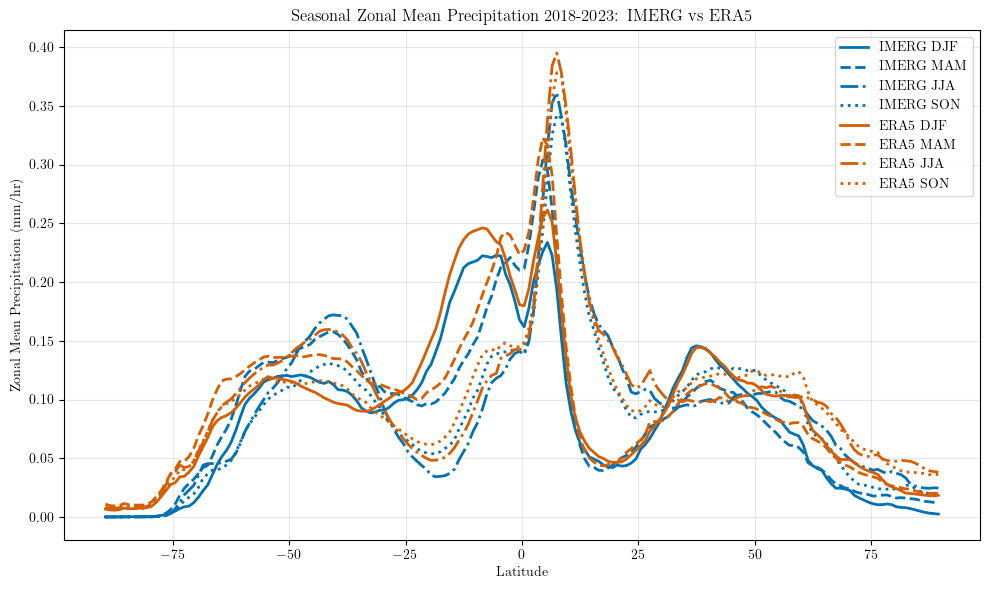

In [6]:
# Plot zonal means for IMERG and ERA5 for all seasons
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

# Update file paths if needed
imerg_file = "/scratch/leko/zonal_means/all_months/IMERG_monthly.nc"
era5_file = "/scratch/leko/zonal_means/all_months/ERA5_monthly.nc"

# Open datasets
imerg = xr.open_dataset(imerg_file)
era5 = xr.open_dataset(era5_file)

# Define seasons
seasons = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11]
}

# Get latitude coordinate name
lat_name = "lat" if "lat" in imerg.coords else "latitude"

# Colorblind-friendly colors (matplotlib tab10)
cb_colors = ["#0072B2", "#D55E00"]  # blue for IMERG, red for ERA5
colors = {"IMERG": cb_colors[0], "ERA5": cb_colors[1]}
linestyles = {"DJF": "-", "MAM": "--", "JJA": "-.", "SON": ":"}

plt.figure(figsize=(10, 6))

for dataset, label in zip([imerg, era5], ["IMERG", "ERA5"]):
    for season, months in seasons.items():
        # Select months, handle December (12) for DJF
        months_sel = months
        # For DJF, need to handle December from previous year
        if season == "DJF":
            da = dataset["pr"].sel(month=months_sel)
            # If December is not present, skip
            if 12 not in dataset["month"]:
                da = da.sel(month=[m for m in months_sel if m != 12])
        else:
            da = dataset["pr"].sel(month=months_sel)
        # Mean over months
        da_season = da.mean("month")
        plt.plot(dataset[lat_name], da_season, label=f"{label} {season}", color=colors[label], linestyle=linestyles[season], linewidth=2)

plt.xlabel("Latitude")
plt.ylabel("Zonal Mean Precipitation (mm/hr)")
plt.title("Seasonal Zonal Mean Precipitation 2018-2023: IMERG vs ERA5")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('zonal_mean_IMERG_ERA5.png')
plt.show()

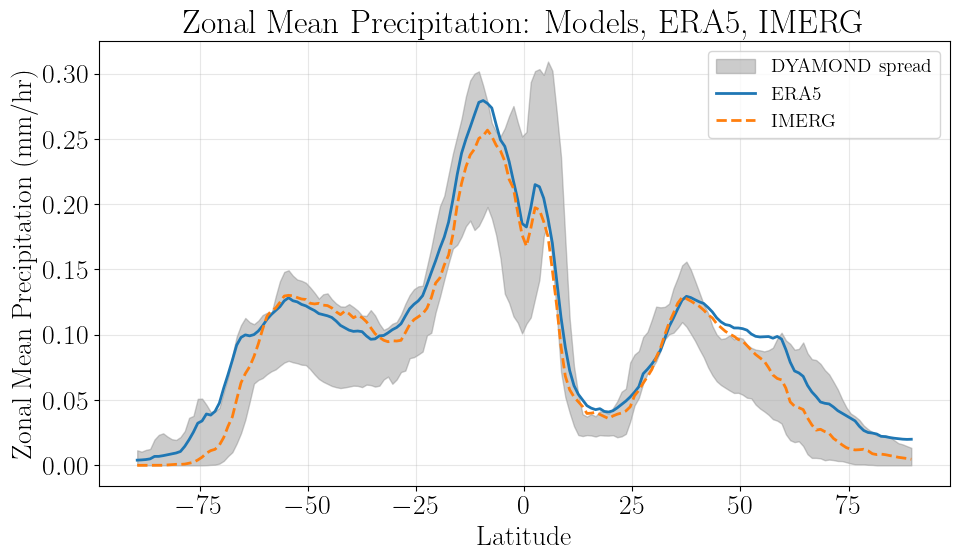

In [45]:
# Path to zonal mean files
data_path = "/scratch/leko/zonal_means/latlon_grid_1deg"

# List of models to plot (update names as needed)
model_files = {
    "ERA5": "ERA5.nc",
    "IMERG": "IMERG.nc",
    "ARPEGE": "ARPEGE.nc",
    "GEOS": "GEOS.nc",
    #"GSAM": "GSAM.nc",
    "ICON": "ICON.nc",
    "IFS": "IFS.nc",
    "SHIELD": "SHIELD.nc"
}

# DYAMOND models (excluding ERA5 and IMERG)
dyamond_models = [k for k in model_files if k not in ["ERA5", "IMERG"]]

import matplotlib as mpl
colors = list(mpl.colormaps['tab10'].colors) + list(mpl.colormaps['tab20'].colors)
# Different line styles for distinction
line_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 2)), (0, (1, 1)), (0, (3, 5, 1, 5))]

plt.figure(figsize=(10, 6))

# Load DYAMOND model data and compute spread
dyamond_lat = None
dyamond_vals = []
for label in dyamond_models:
    fname = model_files[label]
    fpath = os.path.join(data_path, fname)
    if not os.path.exists(fpath):
        print(f"File not found: {fpath}")
        continue
    ds = xr.open_dataset(fpath)
    var = None
    for v in ds.data_vars:
        if "pr" in v or "precipitation" in v or "total_precipitation" in v:
            var = v
            break
    if var is None:
        var = list(ds.data_vars)[0]
    lat_name = "lat" if "lat" in ds.coords else "latitude"
    if dyamond_lat is None:
        dyamond_lat = ds[lat_name].values
    dyamond_vals.append(ds[var].values)

if dyamond_vals:
    dyamond_vals = np.stack(dyamond_vals)
    dyamond_min = np.min(dyamond_vals, axis=0)
    dyamond_max = np.max(dyamond_vals, axis=0)
    plt.fill_between(dyamond_lat, dyamond_min, dyamond_max, color='gray', alpha=0.4, label='DYAMOND spread')

# Plot ERA5 and IMERG as lines
for idx, label in enumerate(["ERA5", "IMERG"]):
    fname = model_files[label]
    fpath = os.path.join(data_path, fname)
    if not os.path.exists(fpath):
        print(f"File not found: {fpath}")
        continue
    ds = xr.open_dataset(fpath)
    var = None
    for v in ds.data_vars:
        if "pr" in v or "precipitation" in v or "total_precipitation" in v:
            var = v
            break
    if var is None:
        var = list(ds.data_vars)[0]
    lat_name = "lat" if "lat" in ds.coords else "latitude"
    plt.plot(ds[lat_name], ds[var], label=label, color=colors[idx], linestyle=line_styles[idx], linewidth=2)

plt.xlabel("Latitude")
plt.ylabel("Zonal Mean Precipitation (mm/hr)")
plt.title("Zonal Mean Precipitation: Models, ERA5, IMERG")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('zonal_mean_DYAMOND_IMERG_ERA5_spread.png')
plt.show()

In [38]:
# Update: Use 'lon' and 'lat' as coordinate names and global range
regions_plot = {
    "Africa": {"color": "#eaac8bff", "lon": [15, 35], "lat": [-20, 5]},
    "Tropical Indian": {"color": "#b56576ff", "lon": [55, 95], "lat": [-20, 0]},
    "Maritime Continent": {"color"
    : "#e56b6fff", "lon": [95, 150], "lat": [-10, 10]},
    "South America": {"color": "#e88c7dff", "lon": [-75, -40], "lat": [-15, 0]},
}

def shift_diurnal_to_local_time(da, hour_dim="hour_of_day", lon_dim="lon"):
    """
    Shift diurnal cycle data from UTC to local solar time based on longitude.
    Supports both hourly (24 steps) and half-hourly (48 steps) data.
    Works for DataArray or Dataset with shape (..., hour_of_day, lat, lon).
    """
    nsteps = da[hour_dim].size
    deg_per_step = 360 / nsteps
    lons = da[lon_dim].values
    shift_steps = np.round(lons / deg_per_step).astype(int)
    shifted = da.copy(deep=True)
    for i, shift in enumerate(shift_steps):
        shifted.loc[{lon_dim: lons[i]}] = da.roll({hour_dim: shift}, roll_coords=False).loc[{lon_dim: lons[i]}]
    return shifted

# Example usage:
# ERA5_local = shift_diurnal_to_local_time(ERA5['pr'], hour_dim='hour_of_day', lon_dim='lon')
# IMERG_local = shift_diurnal_to_local_time(IMERG['pr'], hour_dim='hour_of_day', lon_dim='lon')



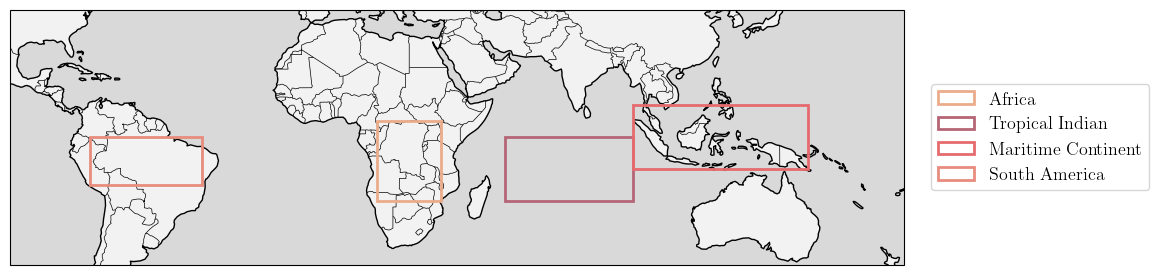

In [42]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle

plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.coastlines(linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='0.95')
ax.add_feature(cfeature.OCEAN, facecolor='0.85')

handles = []
labels = []
# Draw region boxes
for region, props in regions_plot.items():
    lon0, lon1 = props['lon']
    lat0, lat1 = props['lat']
    width = lon1 - lon0
    height = lat1 - lat0
    rect = Rectangle((lon0, lat0), width, height, linewidth=2, edgecolor=props['color'], facecolor='none', zorder=5, label=region)
    ax.add_patch(rect)
    handles.append(rect)
    labels.append(region)
    # Place label at top left of box

ax.set_extent([-100, 180, -40, 40], crs=ccrs.PlateCarree())
#plt.title('Regions Used for Diurnal Cycle Analysis', fontsize=18)
# Place legend outside the plot
ax.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=13, frameon=True)
plt.tight_layout()
plt.savefig('Region_definition.png', dpi=300)
plt.show()


In [17]:
IMERG = xr.open_dataset('/scratch/leko/IMERG/IMERG_1_deg_diurnal/IMERG_diurnal_climatology_2018_2023.nc')
ERA5 = xr.open_dataset('/scratch/leko/ERA5/ERA5_1_deg_diurnal/ERA5_diurnal_climatology_2018_2023.nc')

#

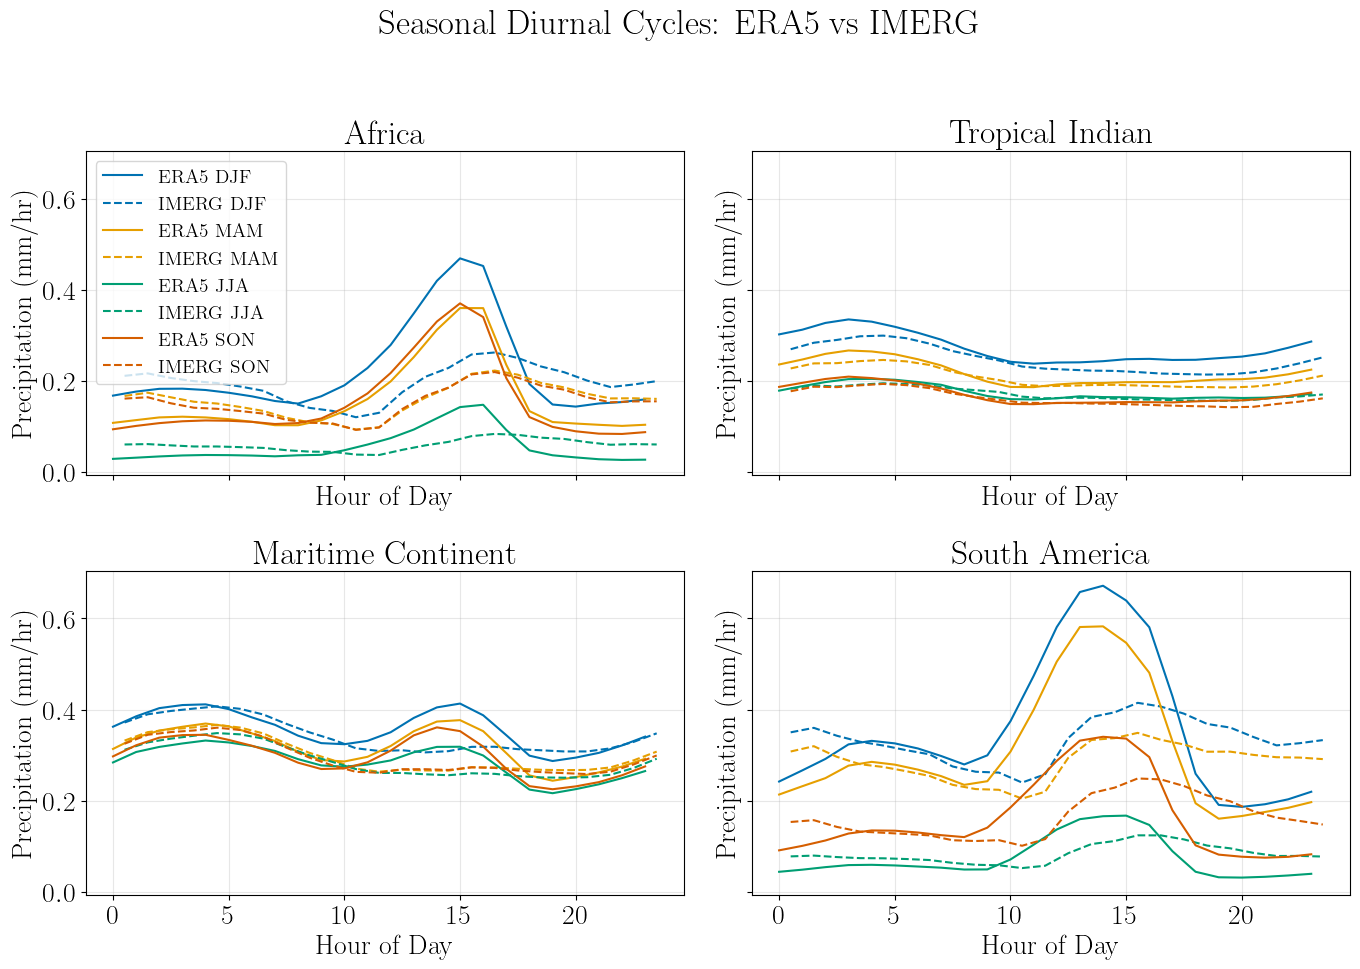

In [44]:
# Define seasons as month lists
seasons = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11]
}

# Weighted mean over region and months
def seasonal_diurnal(ds, var, region, months):
    # Select region
    da = ds[var].sel(lon=slice(region['lon'][0], region['lon'][1]),
                    lat=slice(region['lat'][0], region['lat'][1]))
    # Select months
    da = da.sel(month=months)
    da = shift_diurnal_to_local_time(da, hour_dim='hour_of_day', lon_dim='lon')
    # Calculate weights (cosine of latitude in radians)
    weights = np.cos(np.deg2rad(da['lat']))
    weights.name = "weights"
    # Weighted mean over lat/lon/month
    avg = da.weighted(weights).mean(dim=["lat", "lon", "month"])
    return avg

# Variable names (update if needed)
er_var = 'pr'  # or the correct variable name in ERA5
imerg_var = 'pr'  # or the correct variable name in IMERG

# Colorblind-friendly palette (matplotlib tab10)
season_colors = [
    '#0072B2',  # blue
    '#E69F00',  # orange
    '#009E73',  # green
    '#D55E00'   # red
]

plt.rcParams.update({'font.size': 20, 'axes.titlesize': 24, 'axes.labelsize': 20, 'legend.fontsize': 14, 'xtick.labelsize': 20, 'ytick.labelsize': 20})

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, (region_name, region) in enumerate(regions_plot.items()):
    ax = axes[i]
    for j, (season, months) in enumerate(seasons.items()):
        # ERA5
        era5_cycle = seasonal_diurnal(ERA5, er_var, region, months)
        ax.plot(ERA5['hour_of_day'], era5_cycle, label=f'ERA5 {season}', color=season_colors[j], linestyle='-')
        # IMERG
        imerg_cycle = seasonal_diurnal(IMERG, imerg_var, region, months)
        ax.plot(IMERG['hour_of_day'], imerg_cycle, label=f'IMERG {season}', color=season_colors[j], linestyle='--')
    ax.set_title(region_name)
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Precipitation (mm/hr)')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=14)
plt.suptitle('Seasonal Diurnal Cycles: ERA5 vs IMERG', fontsize=25)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('Regional_diurnal_ERA5_IMERG.png', dpi=300)
plt.show()




In [11]:
xr.open_dataset('/scratch/leko/IMERG/IMERG_1_deg_diurnal/IMERG_diurnal_climatology_2018_2023.nc')

<xarray.Dataset> Size: 75MB
Dimensions:      (month: 12, hour_of_day: 24, lon: 360, lat: 180)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * hour_of_day  (hour_of_day) float64 192B 0.5 1.5 2.5 3.5 ... 21.5 22.5 23.5
  * lon          (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * lat          (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
Data variables:
    pr           (month, hour_of_day, lon, lat) float32 75MB ...

In [16]:
xr.open_dataset('/scratch/leko/ERA5/ERA5_1_deg_diurnal/ERA5_diurnal_climatology_2018_2023.nc')

<xarray.Dataset> Size: 75MB
Dimensions:      (month: 12, hour_of_day: 24, lat: 180, lon: 360)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * hour_of_day  (hour_of_day) float64 192B 0.0 1.0 2.0 3.0 ... 21.0 22.0 23.0
  * lat          (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon          (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Data variables:
    pr           (month, hour_of_day, lat, lon) float32 75MB ...

In [ ]:
# open ERA5 september october november
